# Chonkle Demo: Using Wasm in Codec Pipelines

**chonkle** is a codec pipeline library for encoding and decoding chunked array data. It is capable of mixing standard Python codecs (via numcodecs) with custom WebAssembly codecs.

This notebook first demonstrates a round-trip decode/encode of a COG tile (chunk) using Python codecs, then replaces one of the Python codecs with one written in C and compiled to Wasm. Why Wasm?

1. **Performant** — codecs can be written in languages like C or Rust and run at near-native speed
2. **Portable** — platform-independent binaries
3. **Safe** - sandboxed execution prevents arbitrary code execution and memory corruption
4. **Distributable** — loaded from a local file, HTTPS URL, or OCI registry

## Setup

Run `uv sync --group notebook` from the repo root before starting this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from chunk_utils import cog_metadata, describe_bytes, download_cog, extract_tile

from chonkle import decode, encode

## Get sample data

We'll use a single tile from a Sentinel-2 COG as our test chunk.

### Download a COG

We start by grabbing a red band (B04) COG from [Earth Search](https://earth-search.aws.element84.com/v1).

In [2]:
COG_URL = (
    "https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/"
    "sentinel-2-c1-l2a/10/T/FR/2023/12/"
    "S2B_T10TFR_20231223T190950_L2A/B04.tif"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
COG_PATH = DATA_DIR / "B04.tif"

if not COG_PATH.exists():
    download_cog(COG_URL, COG_PATH)
    print(f"Downloaded {COG_PATH}")
else:
    print(f"Already downloaded: {COG_PATH}")

Downloaded data/B04.tif


### Inspect the COG metadata

We can inspect the downloaded image metadata for information we'll need to build a JSON structure that defines the codec pipeline. Key tags to note:

- **Compression**: 8 = DEFLATE
- **Predictor**: 2 = horizontal differencing
- **TileWidth / TileLength**: 1024
- **SampleFormat / BitsPerSample**: uint16

In [3]:
for name, value in cog_metadata(COG_PATH):
    print(f"{name}: {value}")

ImageWidth: 10980
ImageLength: 10980
BitsPerSample: 16
Compression: 8
PhotometricInterpretation: 1
SamplesPerPixel: 1
PlanarConfiguration: 1
Predictor: 2
TileWidth: 1024
TileLength: 1024
TileOffsets: (55962680, 57411167, 58810332, 60222446, 61651003, 63054996, 64463518, 66025043, 67523672, 68987825, 70439668, 71480485, 72831139, 74191906, 75556803, 76922917, 78346396, 79767466, 81177106, 82626646, 84045343, 85436959, 86443457, 87744763, 89128625, 90516041, 91896145, 93323921, 94699513, 96054131, 97398784, 98768288, 100117176, 101099165, 102475360, 103914015, 105337327, 106767167, 108155055, 109496290, 110853634, 112244713, 113588526, 114895196, 115881834, 117297939, 118737048, 120185270, 121620456, 123031867, 124402930, 125797422, 127166585, 128512496, 129847193, 130813023, 132267746, 133721219, 135168258, 136590051, 138004961, 139387400, 140792216, 142173401, 143531515, 144883653, 145909014, 147512228, 148965842, 150393926, 151820955, 153228408, 154629691, 156014882, 157380367, 158731

### Extract a tile (chunk)

Next, let's extract the raw bytes of tile 0 (the first 1024×1024 pixel block) to use as our test chunk. We'll use the SHA-256 hash as our reference for verifying round-trip (decode then encode) fidelity.

In [4]:
chunk_bytes = extract_tile(COG_PATH, 0)
describe_bytes(chunk_bytes)

size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62


## Python codecs (numcodecs)

Now that we have our test chunk, we can can decode and re-encode the chunk using a pipeline built entirely from Python codecs either native to — or registered with — numcodecs. This establishes is our baseline pipeline that we will eventually modify to use a Wasm codec.

### Codec pipeline

A chonkle codec pipeline is a modified form of [Zarr v3's codec metadata](https://zarr-specs.readthedocs.io/en/latest/v3/core/index.html#metadata) — a JSON list where each entry has a `name` and `configuration`. chonkle adds a `type` field to distinguish between `"numcodecs"` (Python codecs) and `"wasm"` (WebAssembly codecs), and an optional `uri` field for locating Wasm modules.

The list describes the **encoding** order; decoding applies the codecs in reverse.

For this COG tile the encoding pipeline is:

1. `tiff_predictor_2` — horizontal differencing (numpy → numpy)
2. `bytes` — serialize array to raw bytes (numpy → bytes)
3. `zlib` — DEFLATE compression at level 9 (bytes → bytes)

`zlib` is a built-in numcodecs codec. `tiff_predictor_2` and `bytes` are custom `Codec` subclasses that chonkle registers with numcodecs at import time.

In [5]:
codecs_numcodecs = [
    {
        "name": "tiff_predictor_2",
        "type": "numcodecs",
        "configuration": {},
    },
    {
        "name": "bytes",
        "type": "numcodecs",
        "configuration": {
            "endian": "little",
            "data_type": "uint16",
            "shape": [1024, 1024],
        },
    },
    {
        "name": "zlib",
        "type": "numcodecs",
        "configuration": {"level": 9},
    },
]

### Decode

Decoding applies the pipeline in reverse: decompress, deserialize, then undo the predictor. This reverse order is what is needed when we want to decode a chunk loaded from disk or fetched over the network. In our case, the chunk's raw bytes are loaded into the variable `tile_bytes`.

In [6]:
arr = decode(chunk_bytes, codecs_numcodecs)
print(f"shape: {arr.shape}  dtype: {arr.dtype}  min: {arr.min()}  max: {arr.max()}")

shape: (1024, 1024)  dtype: uint16  min: 0  max: 10552


To make the result more tangible, we can plot the numpy array (the decoded chunk) as a 2D image using matplotlib.

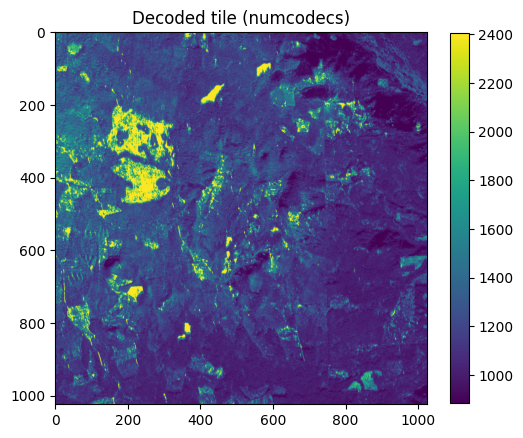

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(arr[arr > 0], [2, 98])
im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax)
ax.set_title("Decoded tile (numcodecs)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

### Encode and verify round trip

Encoding the decoded array back through the same pipeline should produce bytes
identical to the original tile.

In [9]:
encoded = encode(arr, codecs_numcodecs)
describe_bytes(encoded)
assert encoded == chunk_bytes, "Round-trip mismatch!"
print("Round trip: OK")

size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62
Round trip: OK


## Wasm codecs

One of the goals of chonkle is to demonstrate running codecs compiled to WebAssembly, which we will do here by replacing the numcodecs `tiff_predictor_2` codec in the pipeline with a Wasm codec written in C. Since the Wasm codec operates on **raw bytes** rather than numpy arrays, the `bytes` codec must appear **before** the Wasm `tiff_predictor_2` in the pipeline (in encoding order). The Wasm codec also needs explicit configuration for `bytes_per_sample` and `width`.

An additional `uri` field tells chonkle where to find the `.wasm` module. Supported schemes are `file://`, `https://`, and `oci://`. We'll start with a local module, then demonstrate loading the same module from an HTTPS URL and an OCI registry.

In [10]:
wasm_path = Path("tiff-predictor-2-c.wasm").resolve()

codecs_wasm_local = [
    {
        "name": "bytes",
        "type": "numcodecs",
        "configuration": {
            "endian": "little",
            "data_type": "uint16",
            "shape": [1024, 1024],
        },
    },
    {
        "name": "tiff_predictor_2",
        "type": "wasm",
        "uri": wasm_path.as_uri(),
        "configuration": {"bytes_per_sample": 2, "width": 1024},
    },
    {
        "name": "zlib",
        "type": "numcodecs",
        "configuration": {"level": 9},
    },
]

### Local Wasm (`file://`)

We'll decode the same chunk using the Wasm codec loaded from a local file and verify that the result is identical to the array produced by the Python codec pipeline.

In [11]:
arr_wasm = decode(chunk_bytes, codecs_wasm_local)
print(f"shape: {arr_wasm.shape}  dtype: {arr_wasm.dtype}  min: {arr_wasm.min()}  max: {arr_wasm.max()}")

np.testing.assert_array_equal(arr_wasm, arr)
print("Decoded arrays match: OK")

shape: (1024, 1024)  dtype: uint16  min: 0  max: 10552
Decoded arrays match: OK


As before, we'll plot the decoded array to provide a tangible check that the decoded data is equivalent to what we saw before.

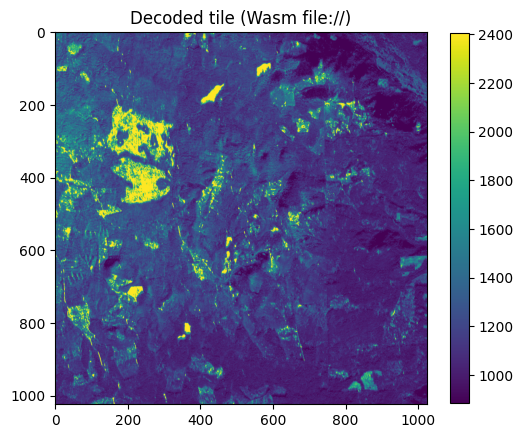

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(arr_wasm[arr_wasm > 0], [2, 98])
im = ax.imshow(arr_wasm, cmap="viridis", vmin=vmin, vmax=vmax)
ax.set_title("Decoded tile (Wasm file://)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

Finally, we'll re-encode the array using the Wasm codec and verify that the resulting bytes are identical to the original chunk we extracted from the COG tile.

In [13]:
encoded_wasm = encode(arr_wasm, codecs_wasm_local)
describe_bytes(encoded_wasm)
assert encoded_wasm == chunk_bytes, "Round-trip mismatch!"
print("Round trip: OK")

size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62
Round trip: OK


### Remote Wasm

Wasm modules can also be fetched from remote sources.
chonkle downloads and caches them automatically.

We test two remote schemes:
- **HTTPS** — a GitHub Releases download
- **OCI** — a container image layer from GitHub Container Registry (GHCR)

#### HTTPS

In [14]:
codecs_wasm_https = [
    {
        "name": "bytes",
        "type": "numcodecs",
        "configuration": {
            "endian": "little",
            "data_type": "uint16",
            "shape": [1024, 1024],
        },
    },
    {
        "name": "tiff_predictor_2",
        "type": "wasm",
        "uri": "https://github.com/cylf-dev/tiff-predictor-2-c/releases/download/v0.1.0/tiff-predictor-2.wasm",
        "configuration": {"bytes_per_sample": 2, "width": 1024},
    },
    {
        "name": "zlib",
        "type": "numcodecs",
        "configuration": {"level": 9},
    },
]

arr_https = decode(chunk_bytes, codecs_wasm_https)
np.testing.assert_array_equal(arr_https, arr)
print("Decoded arrays match: OK")

encoded_https = encode(arr_https, codecs_wasm_https)
describe_bytes(encoded_https)
assert encoded_https == chunk_bytes, "Round-trip mismatch!"
print("Round trip: OK")

Decoded arrays match: OK
size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62
Round trip: OK


#### OCI

In [15]:
codecs_wasm_oci = [
    {
        "name": "bytes",
        "type": "numcodecs",
        "configuration": {
            "endian": "little",
            "data_type": "uint16",
            "shape": [1024, 1024],
        },
    },
    {
        "name": "tiff_predictor_2",
        "type": "wasm",
        "uri": "oci://ghcr.io/cylf-dev/tiff-predictor-2-c:v0.1.0",
        "configuration": {"bytes_per_sample": 2, "width": 1024},
    },
    {
        "name": "zlib",
        "type": "numcodecs",
        "configuration": {"level": 9},
    },
]

arr_oci = decode(chunk_bytes, codecs_wasm_oci)
np.testing.assert_array_equal(arr_oci, arr)
print("Decoded arrays match: OK")

encoded_oci = encode(arr_oci, codecs_wasm_oci)
describe_bytes(encoded_oci)
assert encoded_oci == chunk_bytes, "Round-trip mismatch!"
print("Round trip: OK")

Decoded arrays match: OK
size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62
Round trip: OK


## Summary

chonkle codec pipelines can freely mix Python and WebAssembly codecs. A codec written in C or Rust can be compiled to Wasm and published to a file server, HTTPS endpoint, or OCI registry. Consumers can then drop that codec into their pipeline — it will run safely and at near-native speed, with no platform-specific binaries or manual compilation required.

| Pipeline | tiff_predictor_2 source | Round trip |
| --- | --- | --- |
| numcodecs (Python) | custom registered codec | ✅ |
| Wasm `file://` | local `.wasm` file | ✅ |
| Wasm `https://` | GitHub Releases | ✅ |
| Wasm `oci://` | GitHub Container Registry | ✅ |